In [3]:
import os
import pandas as pd
import sys

project_root = os.path.abspath("..")   # lên 1 cấp: MIND-research

if project_root not in sys.path:
    sys.path.insert(0, project_root)


In [4]:
from src.core.Context import context
from src.urv.URV import URV
from src.recommendation.RecommendationEngine import RecommendationEngine
from src.matrix.Matrix import Metrix
import numpy as np
import pickle

In [3]:
import pickle

behaviours = context.impressions

with open("../vectors/represent_vectors.pkl", "rb") as f:
    represented_vector = pickle.load(f)

urv = URV()

behaviours_list = context.impressions

In [4]:
dict_accuracy = {}

for i in np.arange(0, 1.05, 0.05):
    recommender = RecommendationEngine(represented_vector=represented_vector, alpha=i)
    results = []
    for beha_id, beha_value in behaviours_list.items():
        urv_vector = urv.getURV(beha_value["history"], represented_vector)

        impressions = recommender.calculate_by_impress(user_vector=urv_vector, impressed_list=beha_value["impressions"])
        results.append(Metrix(impressions).evaluate())
        
    auc = np.mean([r["AUC"] for r in results])
    mrr = np.mean([r["MRR"] for r in results])
    ndcg5 = np.mean([r["nDCG@5"] for r in results])
    ndcg10 = np.mean([r["nDCG@10"] for r in results])
    
    dict_accuracy[i] = {"AUC": auc, "MRR": mrr, "nDCG@5": ndcg5, "nDCG@10": ndcg10}
    
    print(f"Alpha: {i:.2f} | AUC: {auc:.4f} | MRR: {mrr:.4f} | nDCG@5: {ndcg5:.4f} | nDCG@10: {ndcg10:.4f}")
    

print("Tuning completed. Results:", dict_accuracy)

Alpha: 0.00 | AUC: 0.5596 | MRR: 0.3163 | nDCG@5: 0.3290 | nDCG@10: 0.3821
Alpha: 0.05 | AUC: 0.5661 | MRR: 0.3203 | nDCG@5: 0.3337 | nDCG@10: 0.3869
Alpha: 0.10 | AUC: 0.5727 | MRR: 0.3246 | nDCG@5: 0.3387 | nDCG@10: 0.3917
Alpha: 0.15 | AUC: 0.5791 | MRR: 0.3286 | nDCG@5: 0.3433 | nDCG@10: 0.3962
Alpha: 0.20 | AUC: 0.5854 | MRR: 0.3324 | nDCG@5: 0.3475 | nDCG@10: 0.4005
Alpha: 0.25 | AUC: 0.5920 | MRR: 0.3361 | nDCG@5: 0.3516 | nDCG@10: 0.4047
Alpha: 0.30 | AUC: 0.5982 | MRR: 0.3393 | nDCG@5: 0.3550 | nDCG@10: 0.4083
Alpha: 0.35 | AUC: 0.6041 | MRR: 0.3425 | nDCG@5: 0.3583 | nDCG@10: 0.4120
Alpha: 0.40 | AUC: 0.6094 | MRR: 0.3453 | nDCG@5: 0.3615 | nDCG@10: 0.4151
Alpha: 0.45 | AUC: 0.6142 | MRR: 0.3476 | nDCG@5: 0.3642 | nDCG@10: 0.4177
Alpha: 0.50 | AUC: 0.6185 | MRR: 0.3498 | nDCG@5: 0.3664 | nDCG@10: 0.4202
Alpha: 0.55 | AUC: 0.6222 | MRR: 0.3517 | nDCG@5: 0.3685 | nDCG@10: 0.4224
Alpha: 0.60 | AUC: 0.6253 | MRR: 0.3532 | nDCG@5: 0.3702 | nDCG@10: 0.4242
Alpha: 0.65 | AUC: 0.6278

In [ ]:
# Luu ket qua tuning de tai lai o cac lan sau, khong can chay tuning lai.
tuning_results_path = "../vectors/tuning_alpha_results.pkl"

with open(tuning_results_path, "wb") as f:
    pickle.dump(dict_accuracy, f)

print(f"Saved tuning results to: {tuning_results_path}")

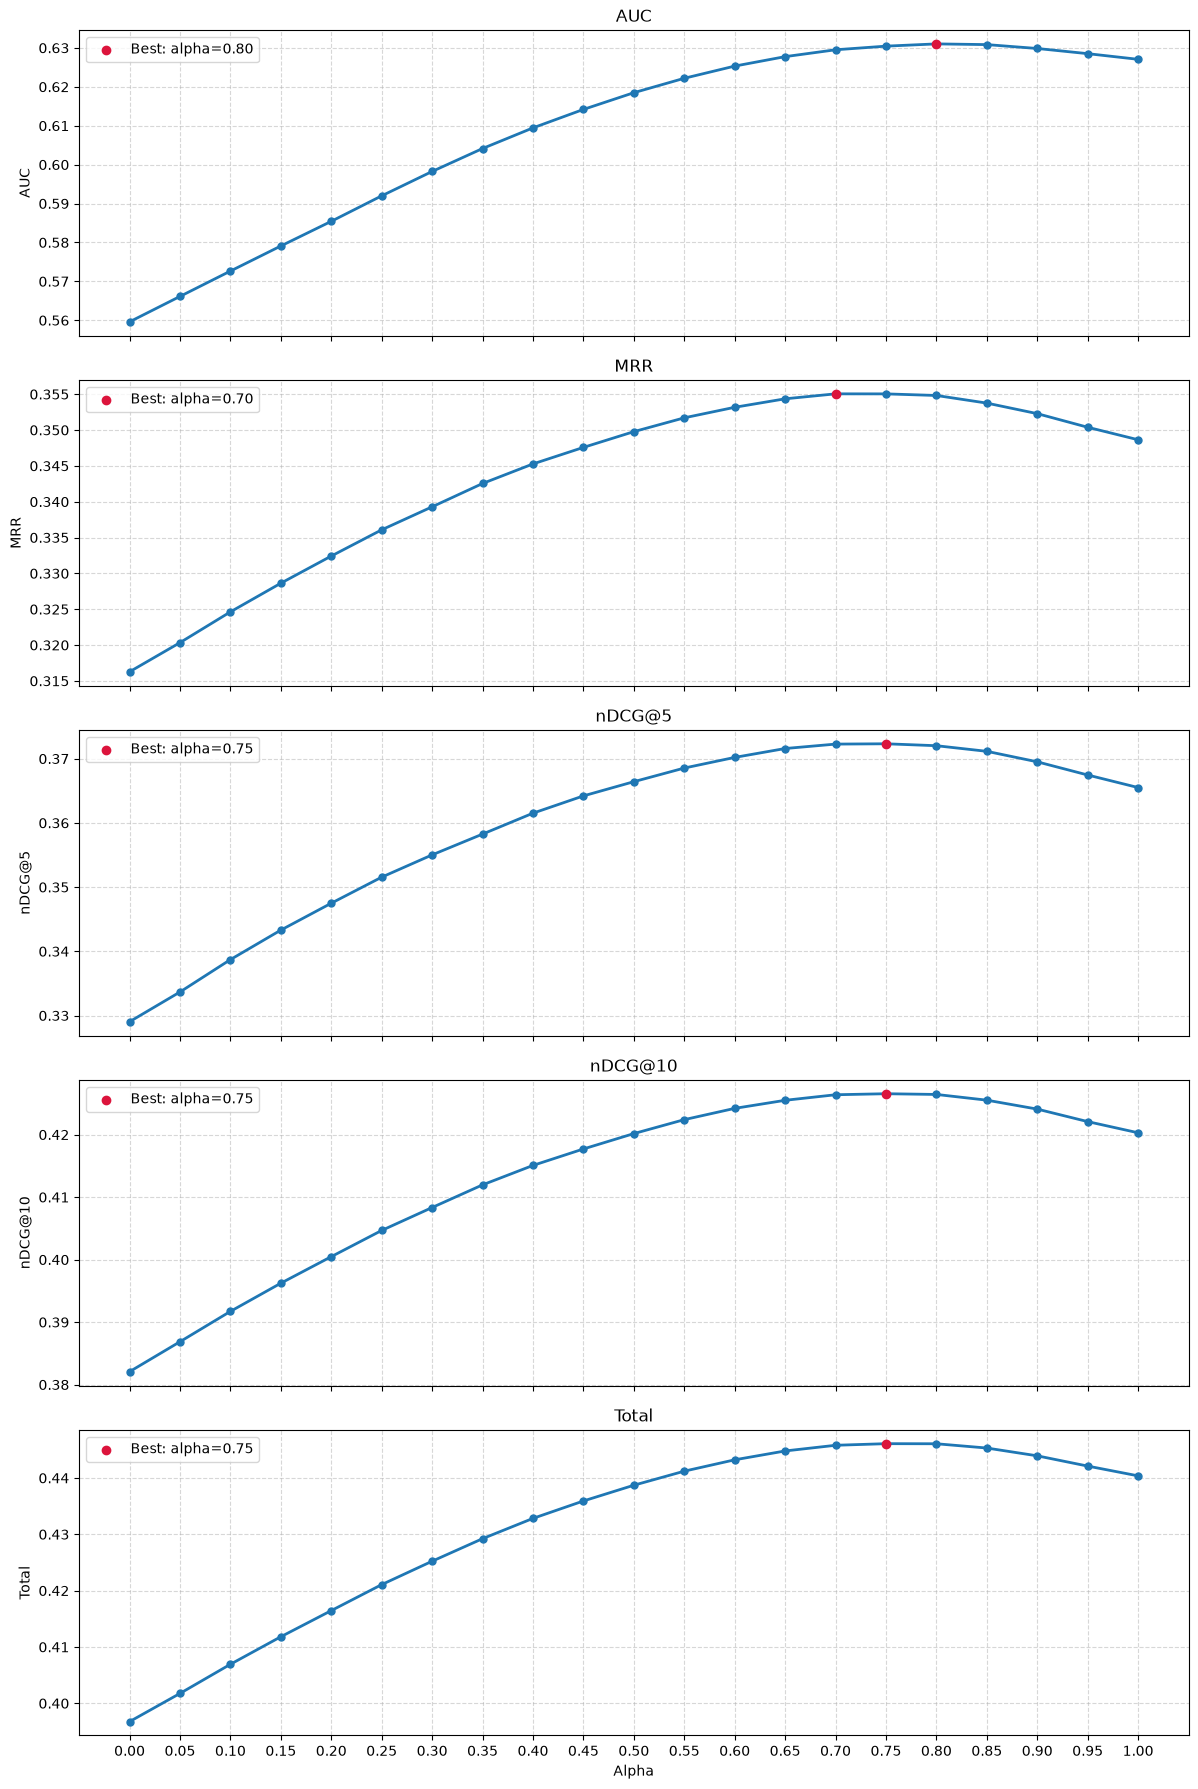

In [6]:
import matplotlib.pyplot as plt

# Doc ket qua da luu, khong can chay lai tuning.
with open("../vectors/tuning_alpha_results.pkl", "rb") as f:
    tuning_results = pickle.load(f)

alphas = sorted(float(alpha) for alpha in tuning_results)
metrics = ["AUC", "MRR", "nDCG@5", "nDCG@10"]
scores = {metric: [float(tuning_results[alpha][metric]) for alpha in alphas] for metric in metrics}

# Tong diem = trung binh cua 4 metrics (tat ca deu nam trong khoang 0-1).
scores["Total"] = np.mean([scores[metric] for metric in metrics], axis=0)

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
for ax, (metric, values) in zip(axes, scores.items()):
    ax.plot(alphas, values, marker="o", linewidth=2, markersize=5)
    best_idx = int(np.argmax(values))
    ax.scatter(alphas[best_idx], values[best_idx], color="crimson", zorder=3, label=f"Best: alpha={alphas[best_idx]:.2f}")
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

axes[-1].set_xlabel("Alpha")
axes[-1].set_xticks(alphas)
plt.tight_layout()
plt.show()